### Emotion Recognition with HuBERT Speech Model

Short Description
This implementation performs speech emotion recognition using a pre-trained HuBERT model from the SUPERB benchmark. It processes audio files to classify emotions into seven categories (angry, disgust, fear, happy, neutral, sad, surprise) and returns probability distributions for each emotion.

Key Libraries Used

    transformers: HuBERT model and feature extractor

    torch: Tensor operations and deep learning framework

    torchaudio: Audio loading and resampling

Code Logic and Flow

High-Level Overview
The workflow loads an audio file, resamples it to 16kHz, extracts acoustic features using a specialized processor, runs inference through a pre-trained HuBERT model, and converts the output logits into emotion probabilities. The system automatically leverages GPU acceleration when available.

Visual FlowChart:

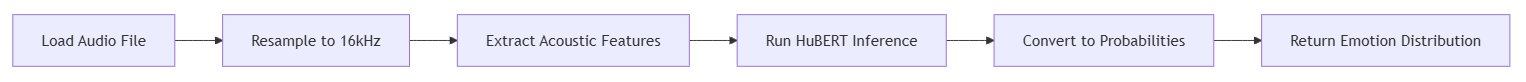

Step-by-Step Code Breakdown

1. Model Initialization

    Loads pre-trained HuBERT model ("superb/hubert-base-superb-er")

    Initializes corresponding Wav2Vec2 feature extractor

    Models are downloaded from Hugging Face Hub

2. Audio Preprocessing

    Loads audio file using TorchAudio

    Resamples to 16kHz if needed using TorchAudio's Resample transform

    Extracts features using Hugging Face feature extractor:

        Converts waveform to input features

        Handles padding automatically

        Returns PyTorch tensors

3. Device Configuration

    Automatically detects available GPU

    Transfers both model and inputs to GPU if available

    Falls back to CPU execution otherwise

4. Emotion Classification

    Runs model inference in no-gradient mode for efficiency

    Processes model outputs through softmax for probabilities

    Maps numerical outputs to emotion labels:

        7 emotion categories from the SUPERB ER benchmark

    Formats probabilities as human-readable percentages

Connecting to the Lecture

    Transfer Learning: Uses pre-trained HuBERT model fine-tuned for emotion recognition

    Acoustic Feature Extraction: Leverages self-supervised learned representations

    Model Efficiency: Automatic device selection optimizes resource usage

    Standardized Sampling: 16kHz resampling ensures model compatibility

    Probability Calibration: Softmax converts logits to interpretable percentages

    Real-world Applicability: Ready-to-use function for emotion analysis pipelines

    Benchmark Integration: Utilizes SUPERB benchmark model for state-of-the-art performance

In [17]:
import torch
import torchaudio
from transformers import HubertForSequenceClassification, Wav2Vec2FeatureExtractor

# Load model
model = HubertForSequenceClassification.from_pretrained("superb/hubert-base-superb-er")
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("superb/hubert-base-superb-er")

def analyze_emotion(file_path):
    # Load audio and resample to 16kHz
    waveform, sample_rate = torchaudio.load(file_path)
    
    # Resample if needed
    if sample_rate != 16000:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sample_rate, 
            new_freq=16000
        )
        waveform = resampler(waveform)
        sample_rate = 16000
    
    # Preprocess audio
    inputs = feature_extractor(
        waveform.squeeze(0), 
        sampling_rate=sample_rate, 
        return_tensors="pt",
        padding=True
    )
    
    # Use CPU or CUDA if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    inputs = {k: v.to(device) for k,v in inputs.items()}
    model.to(device)
    
    # Inference
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Convert to probabilities
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
    emotions = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
    
    return {e: f"{p:.2%}" for e,p in zip(emotions, probabilities[0].tolist())}

# Usage
print(analyze_emotion("speaker1_sample.wav"))

{'angry': '25.48%', 'disgust': '36.38%', 'fear': '25.83%', 'happy': '12.31%'}
